In [19]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from astropy.timeseries import BoxLeastSquares
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import concurrent.futures
import seaborn as sns

In [34]:
df = pd.read_csv("paired_simulation_labels_combined.csv")

In [27]:
# ==========================================
# 1. I/O and Preprocessing Utilities
# ==========================================

def load_classifier_lightcurve(folder_path):
    """
    Rapidly load a classifier light curve. 
    Assumes all files are now header-less 3-column whitespace-delimited format.
    """
    # Prefer drift-corrected files if they exist
    dat_files = glob.glob(os.path.join(folder_path, "*_driftcorrected.dat"))
    if not dat_files:
        dat_files = glob.glob(os.path.join(folder_path, "*.dat"))
        
    if dat_files:
        try:
            # np.loadtxt is extremely fast for header-less numeric files
            # We take all rows, column 0 (Time) and column 1 (Flux)
            data = np.loadtxt(dat_files[0])
            
            # Ensure it's 2D and has at least two columns
            if data.ndim == 2 and data.shape[1] >= 2:
                return data[:, 0], data[:, 1]
            elif data.ndim == 1:
                # Handle edge case where file might only have one row
                return np.array([data[0]]), np.array([data[1]])
                
        except (ValueError, IndexError, OSError) as e:
            print(f"Error loading {dat_files[0]}: {e}")
            return None, None

    return None, None

def lightcurve_to_ppm(time, flux, max_points=6_000):
    """Clean, median-center, and downsample the light curve."""
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    
    # Filter for finite values
    finite = np.isfinite(time) & np.isfinite(flux)
    t = time[finite]
    f = flux[finite]

    # Ensure chronological order
    order = np.argsort(t)
    t = t[order]
    f = f[order]

    # Center around 0
    y_ppm = f - np.nanmedian(f)

    # Downsample for performance if necessary
    if max_points is not None and len(t) > max_points:
        idx = np.linspace(0, len(t) - 1, max_points).astype(int)
        t = t[idx]
        y_ppm = y_ppm[idx]

    # Remove duplicate timestamps
    unique = np.concatenate([[True], np.diff(t) > 0])
    return t[unique], y_ppm[unique]

def robust_noise_ppm(y_ppm):
    """Calculate robust standard deviation using Median Absolute Deviation."""
    dy = np.diff(y_ppm)
    if len(dy) == 0:
        return np.nan
    sigma = 1.4826 * np.nanmedian(np.abs(dy - np.nanmedian(dy))) / np.sqrt(2.0)
    return float(sigma) if np.isfinite(sigma) and sigma > 0 else float(np.nanstd(y_ppm))




In [143]:
def lightcurve_to_ppm(time_seconds, flux, max_points=6_000):
    t = np.asarray(time_seconds, dtype=float) / 86400.0  # convert immediately, unambiguously
    flux = np.asarray(flux, dtype=float)

    finite = np.isfinite(t) & np.isfinite(flux)
    t, flux = t[finite], flux[finite]

    order = np.argsort(t)
    t, flux = t[order], flux[order]

    y_ppm = flux - np.nanmedian(flux)

    if max_points is not None and len(t) > max_points:
        idx = np.linspace(0, len(t) - 1, max_points).astype(int)
        t, y_ppm = t[idx], y_ppm[idx]

    unique = np.concatenate([[True], np.diff(t) > 0])
    return t[unique], y_ppm[unique]

def robust_noise_ppm(y_ppm):
    dy = np.diff(y_ppm)
    if len(dy) == 0:
        return np.nan
    sigma = 1.4826 * np.nanmedian(np.abs(dy - np.nanmedian(dy))) / np.sqrt(2.0)
    return float(sigma) if np.isfinite(sigma) and sigma > 0 else float(np.nanstd(y_ppm))


def extract_bls_features(t_days, y_ppm, min_period=2.0, max_period=100.0,
                         n_periods=160, durations=(0.08, 0.16, 0.32, 0.64)):
    """Box Least Squares transit-search features for a single light curve."""
    span = float(np.nanmax(t_days) - np.nanmin(t_days))
    max_period = min(max_period, 0.8 * span)
    min_period = min(min_period, max_period / 2.0)
    if len(t_days) < 20 or not np.isfinite(max_period) or max_period <= min_period:
        return {
            "bls_power": np.nan,
            "bls_period": np.nan,
            "bls_duration": np.nan,
            "bls_depth_ppm": np.nan,
            "bls_depth_snr": np.nan,
            "bls_transit_time": np.nan,
        }

    periods = np.geomspace(min_period, max_period, n_periods)
    dy_ppm = np.full_like(y_ppm, max(robust_noise_ppm(y_ppm), 1.0))
    model = BoxLeastSquares(t_days, y_ppm, dy=dy_ppm)

    try:
        result = model.power(periods, np.asarray(durations), objective="snr")
        power = np.ravel(result.power).astype(float)
        finite_power = np.where(np.isfinite(power), power, np.nan)
        if np.all(np.isnan(finite_power)):
            raise ValueError("BLS returned no finite powers")

        best = int(np.nanargmax(finite_power))
        depth = float(np.ravel(result.depth)[best])
        depth_err = float(np.ravel(result.depth_err)[best])
        depth_snr = float(abs(depth) / depth_err) if depth_err > 0 else np.nan

        values = {
            "bls_power": float(finite_power[best]),
            "bls_period": float(np.ravel(result.period)[best]),
            "bls_duration": float(np.ravel(result.duration)[best]),
            "bls_depth_ppm": depth,
            "bls_depth_snr": depth_snr,
            "bls_transit_time": float(np.ravel(result.transit_time)[best]),
        }
        return {key: value if np.isfinite(value) else np.nan for key, value in values.items()}
    except Exception:
        return {
            "bls_power": np.nan,
            "bls_period": np.nan,
            "bls_duration": np.nan,
            "bls_depth_ppm": np.nan,
            "bls_depth_snr": np.nan,
            "bls_transit_time": np.nan,
        }

def extract_transit_classifier_features(time, flux, max_points=6_000):
    """Feature vector for transit/no-transit classification."""
    t_days, y_ppm = lightcurve_to_ppm(time, flux, max_points=max_points)
    sigma = robust_noise_ppm(y_ppm)
    percentiles = np.nanpercentile(y_ppm, [1, 5, 10, 50, 90, 95, 99])
    centered = y_ppm - np.nanmedian(y_ppm)

    features = {
        "n_points": len(y_ppm),
        "time_span_days": float(np.nanmax(t_days) - np.nanmin(t_days)),
        "cadence_days": float(np.nanmedian(np.diff(t_days))) if len(t_days) > 1 else np.nan,
        "flux_std_ppm": float(np.nanstd(y_ppm)),
        "noise_ppm": sigma,
        "skew": float(skew(centered, nan_policy="omit")),
        "kurtosis": float(kurtosis(centered, nan_policy="omit")),
        "p01_ppm": float(percentiles[0]),
        "p05_ppm": float(percentiles[1]),
        "p10_ppm": float(percentiles[2]),
        "p90_ppm": float(percentiles[4]),
        "p95_ppm": float(percentiles[5]),
        "p99_ppm": float(percentiles[6]),
        "low_tail_width_ppm": float(percentiles[3] - percentiles[0]),
        "high_tail_width_ppm": float(percentiles[6] - percentiles[3]),
        "negative_outlier_fraction": float(np.mean(y_ppm < -3.0 * sigma)) if np.isfinite(sigma) and sigma > 0 else np.nan,
    }

    return features

def extract_flare_features(time, flux, max_points=6_000):
    """Positive-tail and burst-shape features useful for flare classification."""
    t_days, y_ppm = lightcurve_to_ppm(time, flux, max_points=max_points)
    sigma = robust_noise_ppm(y_ppm)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = max(float(np.nanstd(y_ppm)), 1.0)

    positive = np.clip(y_ppm, 0.0, None)
    above_3 = y_ppm > 3.0 * sigma
    above_5 = y_ppm > 5.0 * sigma

    if len(t_days) > 1:
        cadence = float(np.nanmedian(np.diff(t_days)))
    else:
        cadence = np.nan

    # Longest contiguous positive excursion above 3 sigma
    longest_run = 0
    current_run = 0
    for is_high in above_3:
        if is_high:
            current_run += 1
            longest_run = max(longest_run, current_run)
        else:
            current_run = 0

    max_idx = int(np.nanargmax(y_ppm)) if len(y_ppm) else 0
    local_start = max(0, max_idx - 20)
    local_stop = min(len(y_ppm), max_idx + 21)
    local_window = y_ppm[local_start:local_stop]

    return {
        "flare_max_ppm": float(np.nanmax(y_ppm)),
        "flare_max_snr": float(np.nanmax(y_ppm) / sigma),
        "flare_p99_snr": float(np.nanpercentile(y_ppm, 99) / sigma),
        "flare_positive_area_ppm_day": float(np.nansum(positive) * cadence) if np.isfinite(cadence) else np.nan,
        "flare_positive_fraction_3sigma": float(np.mean(above_3)),
        "flare_positive_fraction_5sigma": float(np.mean(above_5)),
        "flare_longest_run_3sigma": float(longest_run),
        "flare_longest_duration_3sigma_days": float(longest_run * cadence) if np.isfinite(cadence) else np.nan,
        "flare_peak_local_contrast": float(np.nanmax(local_window) - np.nanmedian(local_window)) if len(local_window) else np.nan,
    }

In [144]:
def _process_single_system(args):
    """Helper function to process a single file on a separate CPU core."""
    system_id, anomaly_class, max_points = args
    event_labels = {0: "neither", 1: "flare", 2: "transit", 3: "both"}
    
    time, flux = load_classifier_lightcurve(f"outputs/{system_id}/")
    if time is None:
        return None

    try:
        features = extract_transit_classifier_features(time, flux, max_points=max_points)
        features.update(extract_flare_features(time, flux, max_points=max_points))
        features.update(extract_bls_features(time, flux))
        
        # Add the labels back in
        features.update({
            "system_id": system_id,
            "event_class": event_labels[int(anomaly_class)],
            "anomaly_class": int(anomaly_class),
        })
        return features
    except Exception as exc:
        # Silently fail for corrupted files to keep the parallel pool running
        return None

def build_event_feature_table(labels_df, max_systems=None, max_points=50_000):
    """Builds the feature matrix using multithreading to bypass Jupyter restrictions."""
    event_labels = {0: "neither", 1: "flare", 2: "transit", 3: "both"}
    source_df = labels_df[labels_df["anomaly_class"].isin(event_labels.keys())].copy()
    
    if max_systems is not None:
        source_df = source_df.head(max_systems)

    # Package the arguments for the parallel workers
    tasks = [
        (row["system_id"], row["anomaly_class"], max_points)
        for _, row in source_df.iterrows()
    ]

    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        results = list(tqdm(
            executor.map(_process_single_system, tasks), 
            total=len(tasks), 
            desc="Extracting Features (Threads)"
        ))

    # Filter out any None values from skipped/corrupted files
    valid_rows = [res for res in results if res is not None]

    return pd.DataFrame(valid_rows)

def add_confidence_columns(prediction_df, class_names):
    """Add max probability, probability margin, and normalized entropy confidence diagnostics."""
    prob_cols = [f"p_{name}" for name in class_names]
    probs = prediction_df[prob_cols].to_numpy(dtype=float)
    sorted_probs = np.sort(probs, axis=1)
    top = sorted_probs[:, -1]
    second = sorted_probs[:, -2] if probs.shape[1] > 1 else np.zeros_like(top)
    entropy = -np.sum(np.clip(probs, 1e-12, 1.0) * np.log(np.clip(probs, 1e-12, 1.0)), axis=1)
    max_entropy = np.log(probs.shape[1])

    prediction_df["confidence"] = top
    prediction_df["confidence_margin"] = top - second
    prediction_df["confidence_entropy"] = 1.0 - entropy / max_entropy
    return prediction_df

In [ ]:
# ==========================================
# 4. Training Pipeline Execution
# ==========================================
# Assuming 'df' is your combined labels dataframe loaded previously
event_feature_df = build_event_feature_table(df, max_systems=None, max_points=50_000)

print(f"\nExtracted Features Shape: {event_feature_df.shape}")
print(event_feature_df["event_class"].value_counts())

event_feature_cols = [col for col in event_feature_df.columns if col not in {"system_id", "event_class", "anomaly_class"}]
X_event = event_feature_df[event_feature_cols]
y_event = event_feature_df["event_class"]

X_event_train, X_event_test, y_event_train, y_event_test, event_ids_train, event_ids_test = train_test_split(
    X_event, y_event, event_feature_df["system_id"], test_size=0.25, random_state=42, stratify=y_event
)

# Initialize and train the Random Forest
event_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

Extracting Features (Threads):  59%|█████▊    | 1171/2000 [11:33<06:34,  2.10it/s]

In [ ]:
event_clf.fit(X_event_train, y_event_train)
event_classes = list(event_clf.named_steps["model"].classes_)

# Predictions and probabilities
event_proba = event_clf.predict_proba(X_event_test)
event_pred = event_clf.predict(X_event_test)

print("\nConfusion Matrix (Rows=True, Columns=Predicted):")
print(pd.DataFrame(
    confusion_matrix(y_event_test, event_pred, labels=event_classes),
    index=[f"true_{name}" for name in event_classes],
    columns=[f"pred_{name}" for name in event_classes],
))

print("\nClassification Report:")
print(classification_report(y_event_test, event_pred, labels=event_classes))

# Compile results dataframe
probability_df = pd.DataFrame(event_proba, columns=[f"p_{name}" for name in event_classes])

event_results_df = pd.concat([
    pd.DataFrame({
        "system_id": event_ids_test.values,
        "true_event_class": y_event_test.values,
        "pred_event_class": event_pred,
    }).reset_index(drop=True),
    probability_df.reset_index(drop=True),
], axis=1)

event_results_df = add_confidence_columns(event_results_df, event_classes)
event_results_df = event_results_df.sort_values("confidence", ascending=False)

# Optional: Master diagnostic table to merge physical params back in
full_analysis = pd.merge(event_results_df, df, on="system_id", how="inner")


Confusion Matrix (Rows=True, Columns=Predicted):
              pred_both  pred_flare  pred_neither  pred_transit
true_both            43          40            12             1
true_flare           20          66             7             1
true_neither          0           0            76            16
true_transit          1           0            46            43

Classification Report:
              precision    recall  f1-score   support

        both       0.67      0.45      0.54        96
       flare       0.62      0.70      0.66        94
     neither       0.54      0.83      0.65        92
     transit       0.70      0.48      0.57        90

    accuracy                           0.61       372
   macro avg       0.63      0.61      0.60       372
weighted avg       0.63      0.61      0.60       372



/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


                      prob  count
bin                              
(0.117, 1.165]    0.207317     82
(1.165, 2.192]    0.315789     38
(2.192, 3.219]    0.700000     20
(3.219, 4.246]    1.000000     15
(4.246, 5.273]    1.000000     13
(5.273, 6.3]      1.000000      4
(6.3, 7.327]      1.000000      4
(7.327, 8.354]    1.000000      4
(8.354, 9.381]    1.000000      2
(9.381, 10.408]   1.000000      2
(10.408, 11.435]  0.000000      1
(19.65, 20.677]   1.000000      1


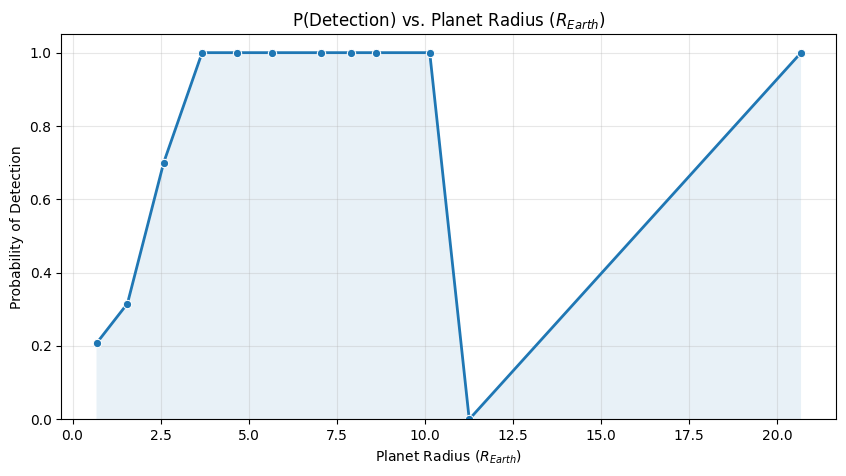

In [ ]:
def plot_detection_probability(df_analysis, feature_col, label, bins=10):
    # Filter only for systems that actually HAVE a transit
    transit_systems = df_analysis[df_analysis['true_event_class'].isin(['transit', 'both'])].copy()
    
    # A "detection" is when the model correctly identifies a transit component
    transit_systems['is_detected'] = transit_systems['pred_event_class'].isin(['transit', 'both']).astype(int)
    
    # Create bins
    transit_systems['bin'] = pd.cut(transit_systems[feature_col], bins=bins)
    
    # Calculate P(detection) per bin
    bin_stats = transit_systems.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1)

    print(bin_stats[['prob', 'count']])
    
    plt.title(f"P(Detection) vs. {label}")
    plt.xlabel(label)
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# Run for Planet Radius
plot_detection_probability(full_analysis, 'transit_radius_earth', "Planet Radius ($R_{Earth}$)", bins=20)

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Stats for No Drift only:
                    prob  count
bin                            
(0.128, 0.63]   0.187500     16
(0.63, 1.123]   0.111111     27
(1.123, 1.615]  0.047619     21
(1.615, 2.107]  0.285714      7
(2.107, 2.6]    0.625000      8
(2.6, 3.092]    1.000000      4
(3.092, 3.585]  1.000000      3
(3.585, 4.077]  1.000000      7
(4.077, 4.569]  1.000000      9
(4.569, 5.062]  1.000000      5
(5.062, 5.554]  1.000000      2
(5.554, 6.046]  1.000000      2
(6.539, 7.031]  1.000000      1
(7.031, 7.524]  1.000000      2
(7.524, 8.016]  1.000000      1
(8.016, 8.508]  1.000000      1
(8.508, 9.001]  1.000000      1
(9.493, 9.986]  1.000000      1


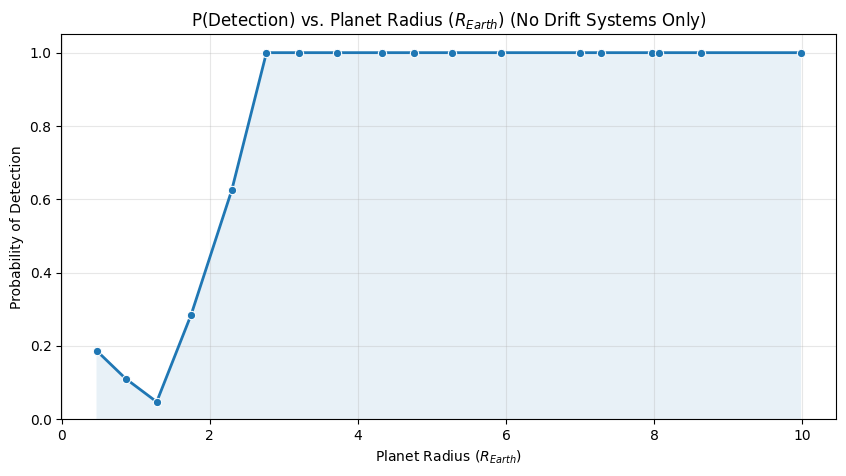

In [ ]:
def plot_detection_probability_low_drift(df_analysis, feature_col, label, bins=10, drift_col='drift'):
    # 1. Filter for LOW DRIFT systems first
    # Adjust 'low' if your data uses a different label (e.g., 'none', 'low')
    df_low = df_analysis[df_analysis[drift_col] == 'none'].copy()
    
    # 2. Filter for systems that actually have a transit
    transit_systems = df_low[df_low['true_event_class'].isin(['transit', 'both'])].copy()
    
    # A "detection" is when the model correctly identifies a transit component
    transit_systems['is_detected'] = transit_systems['pred_event_class'].isin(['transit', 'both']).astype(int)
    
    # Create bins
    transit_systems['bin'] = pd.cut(transit_systems[feature_col], bins=bins)
    
    # Calculate P(detection) per bin
    bin_stats = transit_systems.groupby('bin', observed=True).agg(
        prob=('is_detected', 'mean'),
        midpoint=(feature_col, 'median'),
        count=('is_detected', 'count')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x='midpoint', y='prob', marker='o', linewidth=2)
    plt.fill_between(bin_stats['midpoint'], 0, bin_stats['prob'], alpha=0.1)

    print(f"Stats for No Drift only:")
    print(bin_stats[['prob', 'count']])
    
    plt.title(f"P(Detection) vs. {label} (No Drift Systems Only)")
    plt.xlabel(label)
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()

# Run it
plot_detection_probability_low_drift(full_analysis, 'transit_radius_earth', "Planet Radius ($R_{Earth}$)", bins=20)

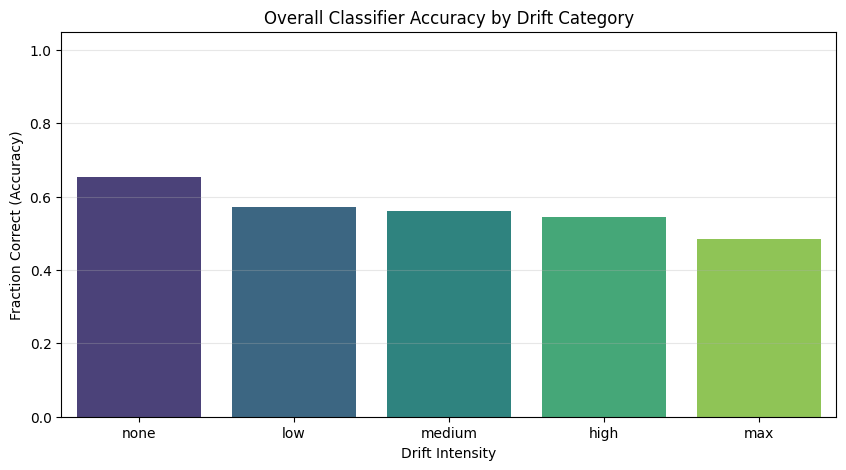

In [ ]:
def plot_accuracy_vs_drift_categorical(df_analysis, drift_col='drift'):
    # 1. Define order
    drift_order = ['none', 'low', 'medium', 'high', 'max']
    
    # 2. Calculate accuracy: Did the model guess the class correctly?
    df_analysis['is_correct'] = (df_analysis['pred_event_class'] == df_analysis['true_event_class']).astype(int)
    
    # 3. Group by category and calculate the mean (fraction correct)
    # We use reindex to enforce your specific order
    stats = df_analysis.groupby(drift_col, observed=True)['is_correct'].mean().reindex(drift_order)
    
    # 4. Plot
    plt.figure(figsize=(10, 5))
    # Using 'hue' is required by modern Seaborn to avoid the FutureWarning
    sns.barplot(x=stats.index, y=stats.values, hue=stats.index, palette='viridis', legend=False)
    
    plt.title("Overall Classifier Accuracy by Drift Category")
    plt.ylabel("Fraction Correct (Accuracy)")
    plt.xlabel("Drift Intensity")
    plt.ylim(0, 1.05)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run it
plot_accuracy_vs_drift_categorical(full_analysis, drift_col='drift')

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Flare Detection Statistics by Bin:
                        efficiency  count
amp_bin                                  
(502.708, 700.34]         0.428571     14
(700.34, 975.666]         0.842105     19
(975.666, 1359.234]       1.000000     21
(1359.234, 1893.594]      0.666667     18
(1893.594, 2638.028]      1.000000     16
(2638.028, 3675.125]      1.000000     14
(3675.125, 5119.94]       0.952381     21
(5119.94, 7132.759]       0.904762     21
(7132.759, 9936.884]      1.000000     15
(9936.884, 13843.405]     1.000000     13
(13843.405, 19285.709]    0.941176     17


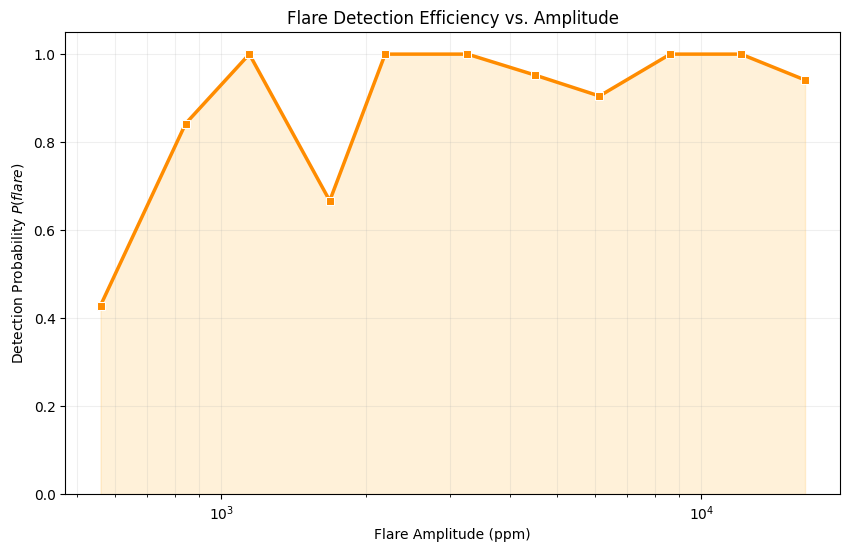

In [ ]:
def plot_flare_detection_efficiency(df_analysis, bins=12):
    # 1. Filter for systems that actually HAVE a flare (Flare or Both)
    flare_systems = df_analysis[df_analysis['true_event_class'].isin(['flare', 'both'])].copy()
    
    # 2. A detection is when the model correctly identifies a flare component
    # We ignore the transit part for this specific analysis.
    flare_systems['flare_detected'] = flare_systems['pred_event_class'].isin(['flare', 'both']).astype(int)
    
    # 3. Create log-spaced bins for amplitude to handle the wide dynamic range
    # Ensure amplitude is > 0 for log spacing
    min_amp = flare_systems['flare_amplitude'].replace(0, np.nan).min()
    max_amp = flare_systems['flare_amplitude'].max()
    
    log_bins = np.logspace(np.log10(min_amp), np.log10(max_amp), bins)
    flare_systems['amp_bin'] = pd.cut(flare_systems['flare_amplitude'], bins=log_bins)
    
    # 4. Calculate P(detection) per bin
    stats = flare_systems.groupby('amp_bin', observed=True).agg(
        efficiency=('flare_detected', 'mean'),
        midpoint=('flare_amplitude', 'median'),
        count=('flare_detected', 'count')
    )

    # 5. Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stats, x='midpoint', y='efficiency', marker='s', color='darkorange', linewidth=2.5)
    plt.fill_between(stats['midpoint'], 0, stats['efficiency'], color='orange', alpha=0.15)
    
    plt.xscale('log')
    plt.title("Flare Detection Efficiency vs. Amplitude")
    plt.xlabel("Flare Amplitude (ppm)")
    plt.ylabel("Detection Probability $P(flare)$")
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    print("Flare Detection Statistics by Bin:")
    print(stats[['efficiency', 'count']])
    
    plt.show()

# Run the analysis on your test set results
plot_flare_detection_efficiency(full_analysis)

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


Flare Detection Statistics (No Drift) by Bin:
                        efficiency  count
amp_bin                                  
(504.609, 702.746]             0.8      5
(702.746, 978.683]             0.9     10
(978.683, 1362.968]            1.0     15
(1362.968, 1898.145]           1.0      7
(1898.145, 2643.463]           1.0      9
(2643.463, 3681.433]           1.0     11
(3681.433, 5126.969]           1.0     17
(5126.969, 7140.102]           1.0     14
(7140.102, 9943.703]           1.0      7
(9943.703, 13848.154]          1.0      8
(13848.154, 19285.709]         1.0     12


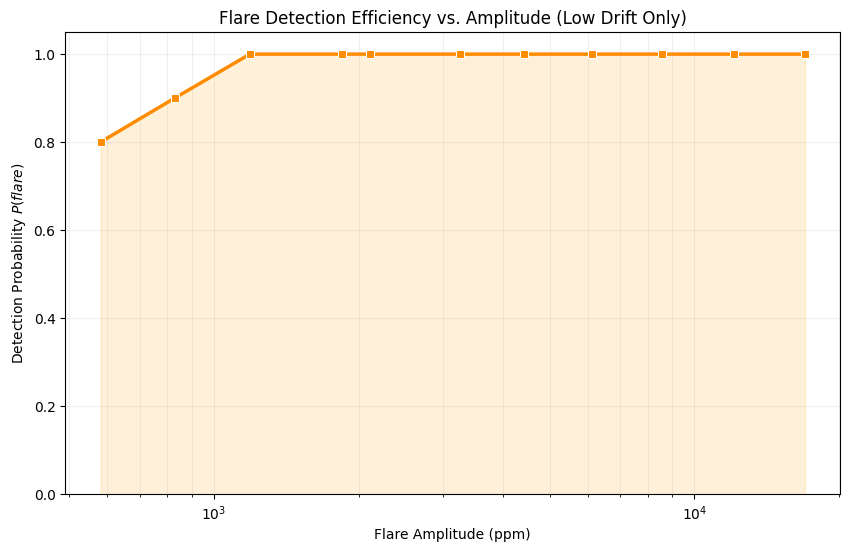

In [ ]:
def plot_flare_detection_efficiency_low_drift(df_analysis, bins=12, drift_col='drift'):
    # 1. Filter for LOW DRIFT systems first
    df_low = df_analysis[df_analysis[drift_col] == 'none'].copy()
    
    # 2. Filter for systems that actually HAVE a flare (Flare or Both)
    flare_systems = df_low[df_low['true_event_class'].isin(['flare', 'both'])].copy()
    
    # 3. A detection is when the model correctly identifies a flare component
    flare_systems['flare_detected'] = flare_systems['pred_event_class'].isin(['flare', 'both']).astype(int)
    
    # 4. Create log-spaced bins for amplitude
    min_amp = flare_systems['flare_amplitude'].replace(0, np.nan).min()
    max_amp = flare_systems['flare_amplitude'].max()
    
    log_bins = np.logspace(np.log10(min_amp), np.log10(max_amp), bins)
    flare_systems['amp_bin'] = pd.cut(flare_systems['flare_amplitude'], bins=log_bins)
    
    # 5. Calculate P(detection) per bin
    stats = flare_systems.groupby('amp_bin', observed=True).agg(
        efficiency=('flare_detected', 'mean'),
        midpoint=('flare_amplitude', 'median'),
        count=('flare_detected', 'count')
    )

    # 6. Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=stats, x='midpoint', y='efficiency', marker='s', color='darkorange', linewidth=2.5)
    plt.fill_between(stats['midpoint'], 0, stats['efficiency'], color='orange', alpha=0.15)
    
    plt.xscale('log')
    plt.title("Flare Detection Efficiency vs. Amplitude (Low Drift Only)")
    plt.xlabel("Flare Amplitude (ppm)")
    plt.ylabel("Detection Probability $P(flare)$")
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    print("Flare Detection Statistics (No Drift) by Bin:")
    print(stats[['efficiency', 'count']])
    
    plt.show()

# Run for low drift only
plot_flare_detection_efficiency_low_drift(full_analysis, drift_col='drift')

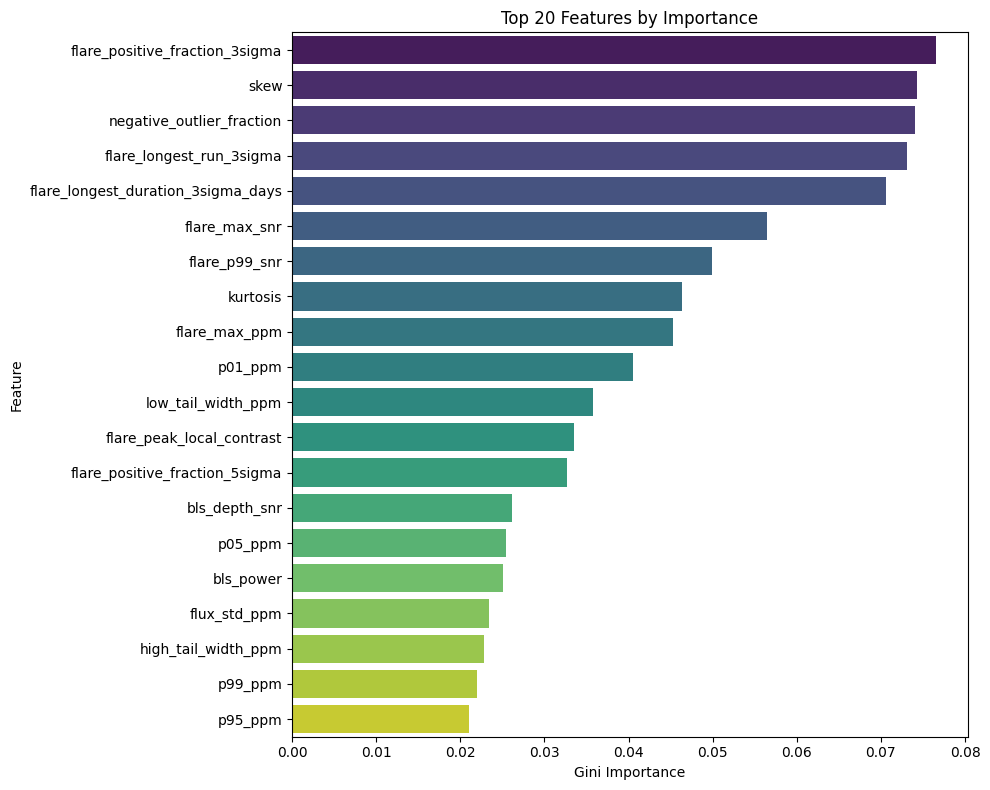

In [ ]:
def plot_feature_importance(clf, feature_names, top_n=20):
    # Extract the random forest from the pipeline
    rf_model = clf.named_steps['model']
    importances = rf_model.feature_importances_
    
    # Create a dataframe for plotting
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
    plt.title(f"Top {top_n} Features by Importance")
    plt.xlabel("Gini Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Run it
plot_feature_importance(event_clf, event_feature_cols)

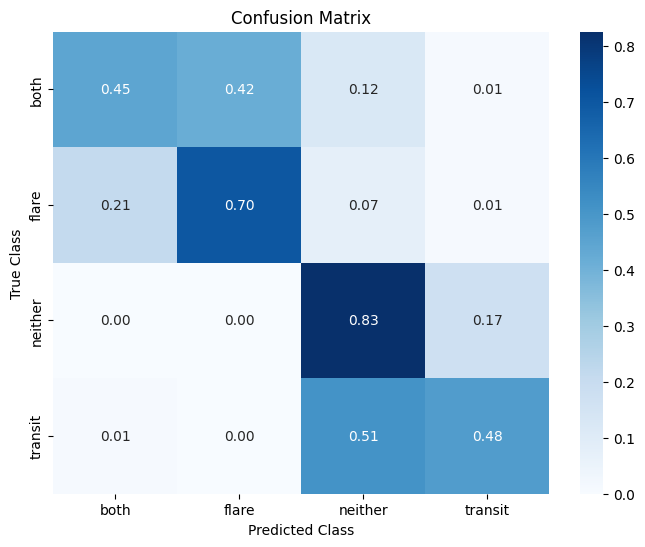

              precision    recall  f1-score   support

        both       0.67      0.45      0.54        96
       flare       0.62      0.70      0.66        94
     neither       0.54      0.83      0.65        92
     transit       0.70      0.48      0.57        90

    accuracy                           0.61       372
   macro avg       0.63      0.61      0.60       372
weighted avg       0.63      0.61      0.60       372



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, xticklabels=labels, yticklabels=labels, cmap='Blues', fmt='.2f')
    plt.title("Confusion Matrix")
    plt.ylabel("True Class")
    plt.xlabel("Predicted Class")
    plt.show()

# Run it
y_pred = event_clf.predict(X_event_test)
plot_confusion_matrix(y_event_test, y_pred, labels=event_clf.classes_)
print(classification_report(y_event_test, y_pred))

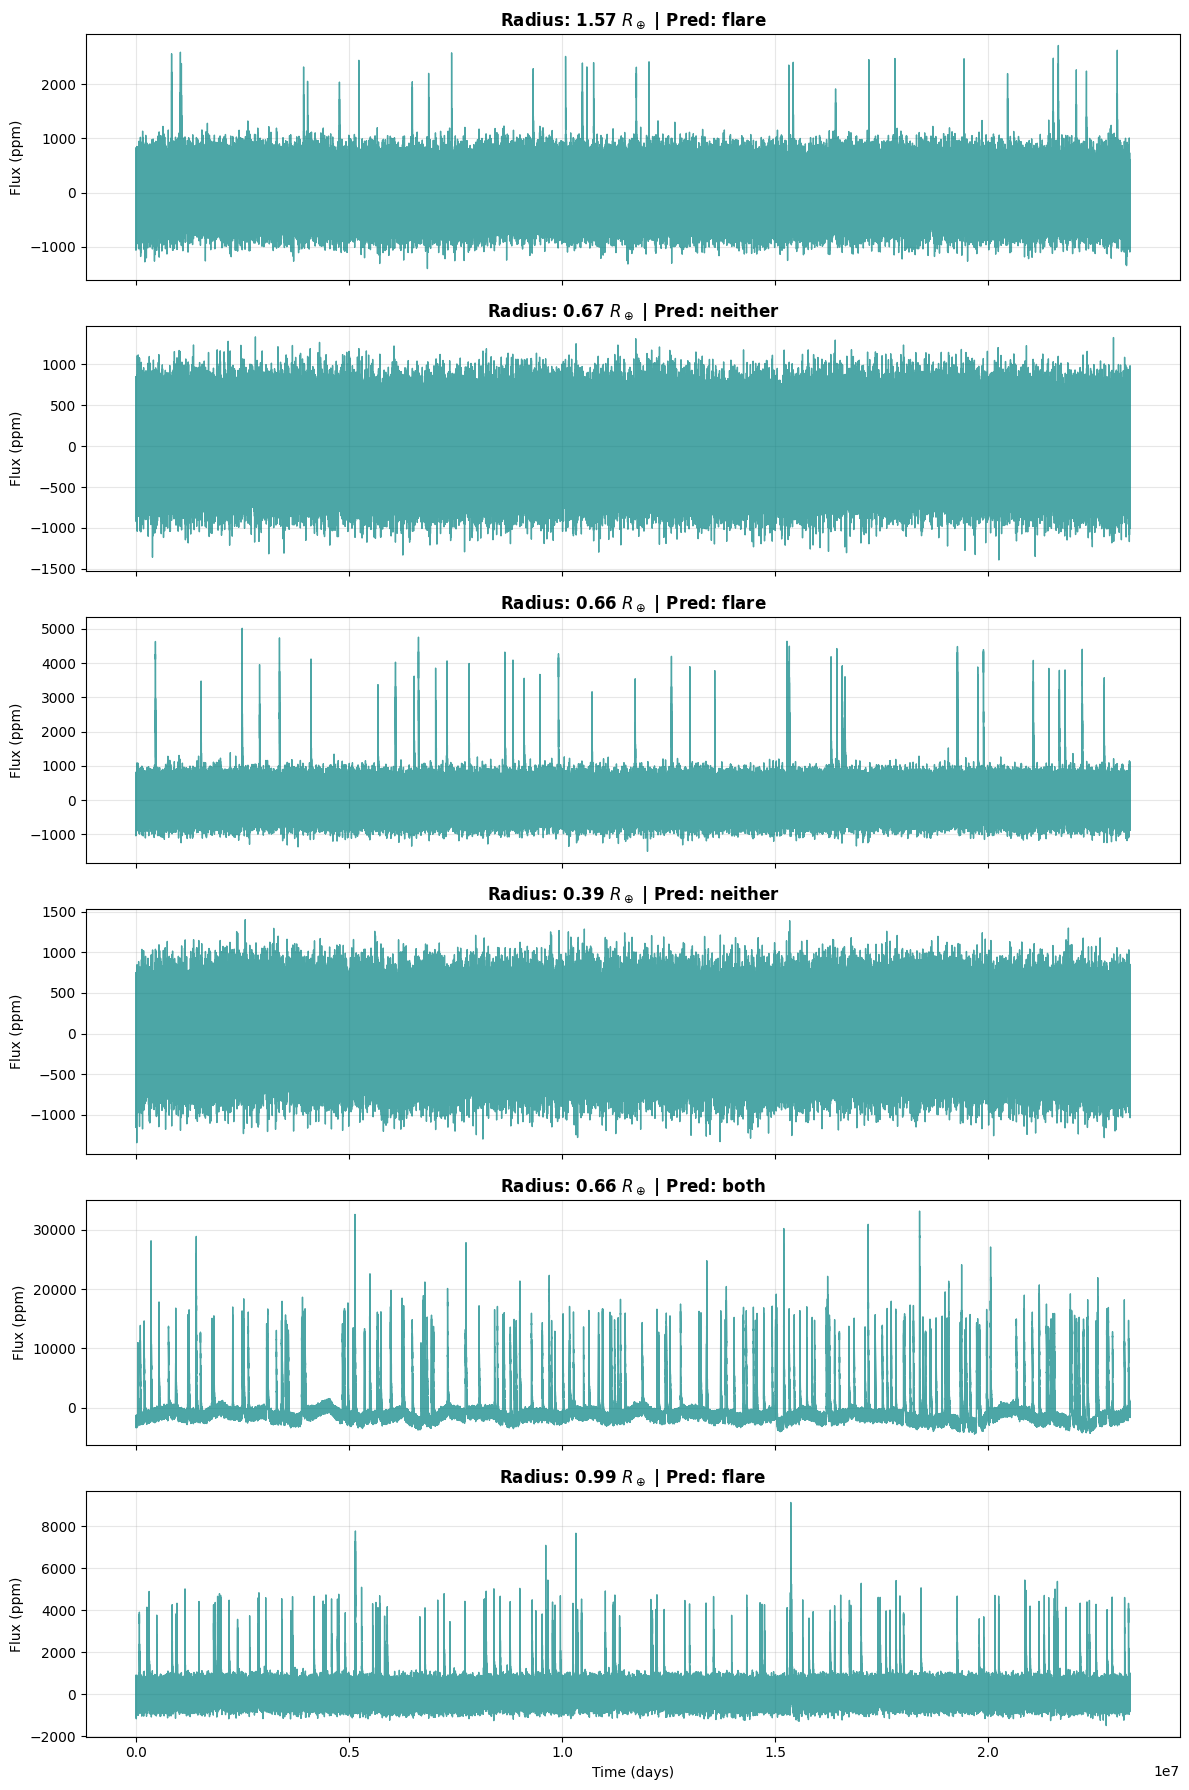

In [ ]:
def plot_difficult_planets(df_analysis, radius_threshold=2.0, n_samples=5):
    # 1. Isolate the "difficult" systems: Sub-2 Earth Radii, Transits present
    mask = (df_analysis['true_event_class'].isin(['transit', 'both'])) & \
           (df_analysis['transit_radius_earth'] < radius_threshold)
    
    difficult_df = df_analysis[mask].sample(min(n_samples, len(df_analysis[mask])))
    
    # 2. Plotting loop
    fig, axes = plt.subplots(len(difficult_df), 1, figsize=(12, 3 * len(difficult_df)), sharex=True)
    if len(difficult_df) == 1: axes = [axes]
    
    for ax, (_, row) in zip(axes, difficult_df.iterrows()):
        # Load the data
        time, flux = load_classifier_lightcurve(f"outputs/{row['system_id']}/")
        
        # Plot flux
        ax.plot(time, flux, color='teal', alpha=0.7, linewidth=1, label='Flux')
        
        # Styling
        title = f"Radius: {row['transit_radius_earth']:.2f} $R_\oplus$ | Pred: {row['pred_event_class']}"
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel("Flux (ppm)")
        ax.grid(alpha=0.3)
        
    plt.xlabel("Time (days)")
    plt.tight_layout()
    plt.show()

# Run it
plot_difficult_planets(full_analysis, radius_threshold=2.0, n_samples=6)

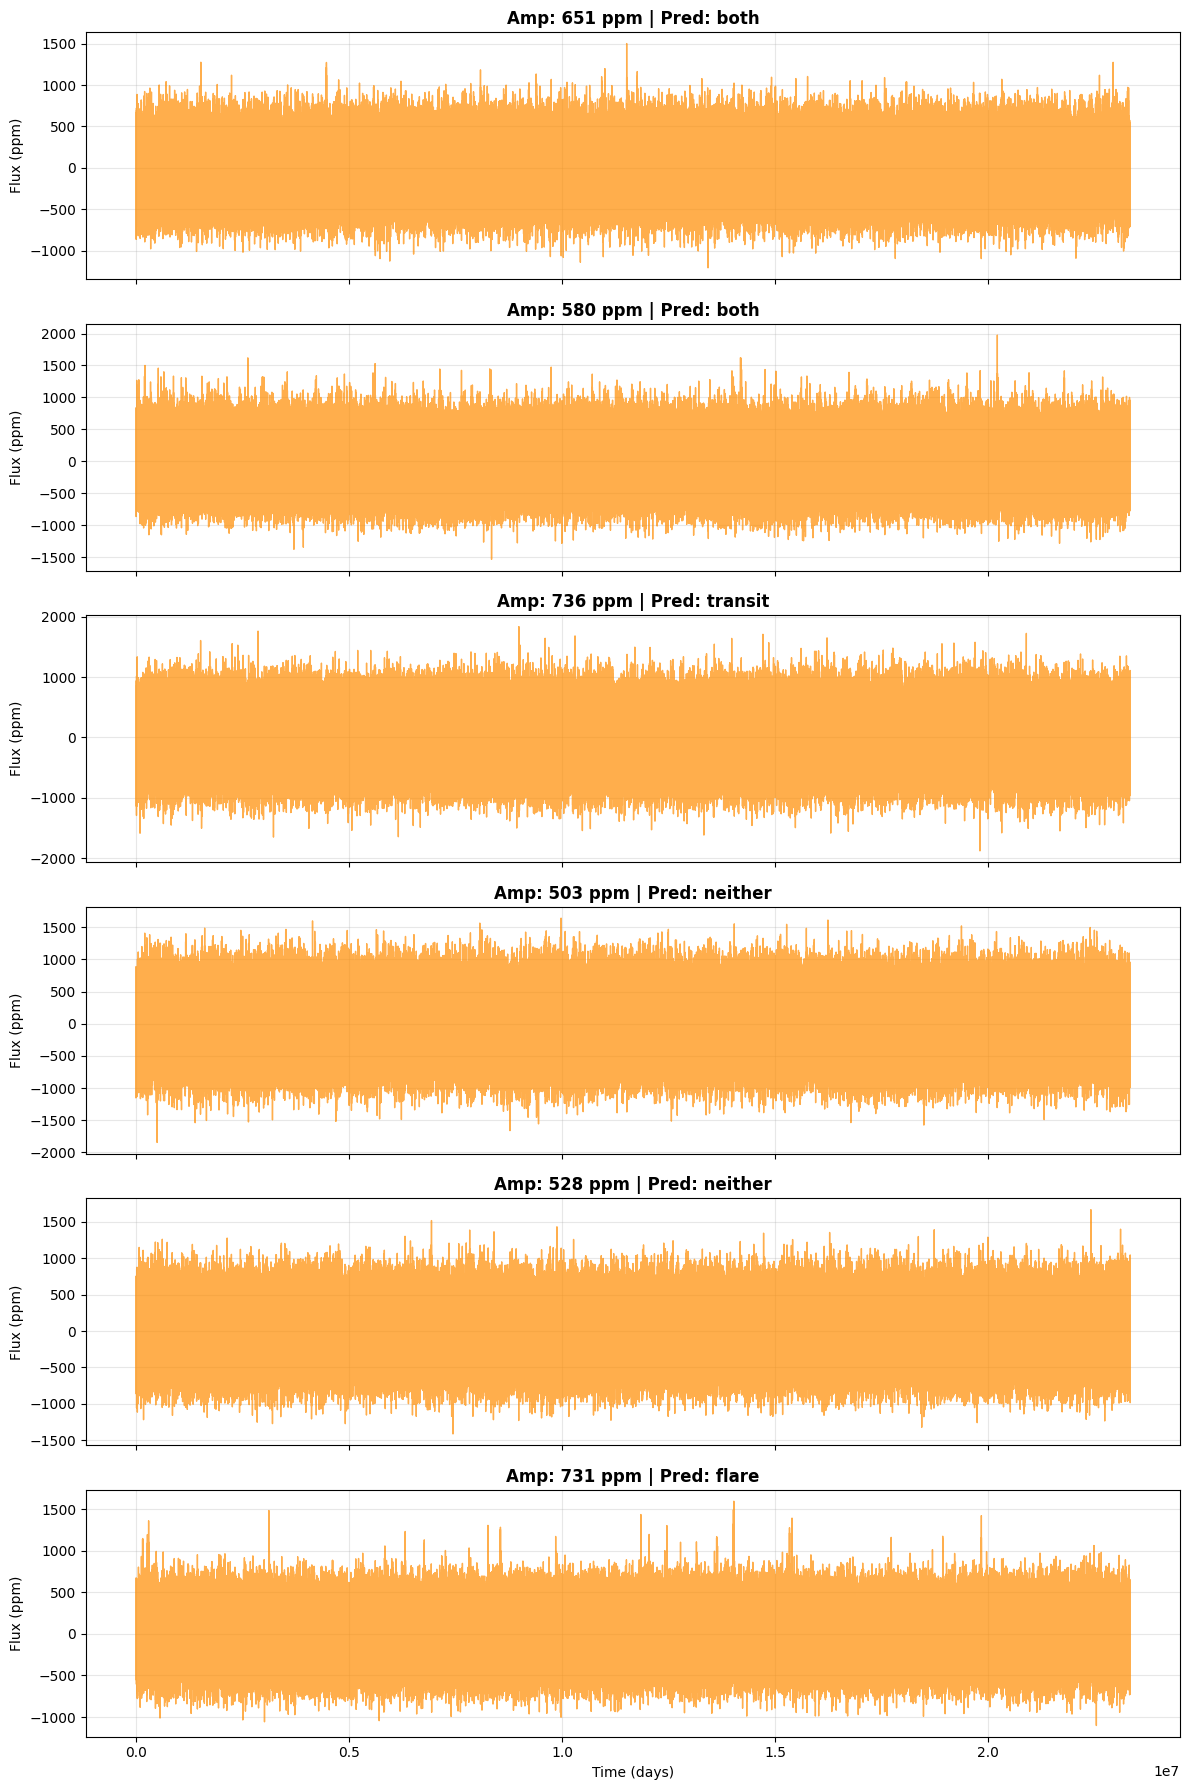

In [ ]:
def plot_difficult_flares(df_analysis, amp_threshold=500, n_samples=6):
    mask = (df_analysis['true_event_class'].isin(['flare', 'both'])) & \
           (df_analysis['flare_amplitude'] < amp_threshold)
    
    difficult_df = df_analysis[mask].sample(min(n_samples, len(df_analysis[mask])))
    
    # Check if we actually found any systems
    if len(difficult_df) == 0:
        print(f"No flares found with amplitude < {amp_threshold}. Try increasing the threshold!")
        return
    
    # 2. Plotting loop
    fig, axes = plt.subplots(len(difficult_df), 1, figsize=(12, 3 * len(difficult_df)), sharex=True)
    if len(difficult_df) == 1: axes = [axes]
    
    for ax, (_, row) in zip(axes, difficult_df.iterrows()):
        time, flux = load_classifier_lightcurve(f"outputs/{row['system_id']}/")
        
        ax.plot(time, flux, color='darkorange', alpha=0.7, linewidth=1)
        
        title = f"Amp: {row['flare_amplitude']:.0f} ppm | Pred: {row['pred_event_class']}"
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel("Flux (ppm)")
        ax.grid(alpha=0.3)
        
    plt.xlabel("Time (days)")
    plt.tight_layout()
    plt.show()

# Run it with a higher threshold if the previous one was empty
plot_difficult_flares(full_analysis, amp_threshold=750, n_samples=6)

In [ ]:
def inspect_failed_system_features(df_analysis, event_feature_df, n_samples=5):
    # 1. Identify systems that were actually transits (radius < 2) but labeled 'neither'
    failures = df_analysis[
        (df_analysis['true_event_class'].isin(['both', 'transit'])) & 
        (df_analysis['transit_radius_earth'] < 2.0) & 
        (df_analysis['pred_event_class'] == 'neither')
    ]
    
    if failures.empty:
        print("No failures found for sub-2 Earth radii planets.")
        return

    # 2. Merge with the features we fed the model
    failed_ids = failures['system_id'].unique()
    failed_features = event_feature_df[event_feature_df['system_id'].isin(failed_ids)]
    
    # 3. Look at the specific BLS features the model saw
    bls_cols = ['bls_power', 'bls_depth_ppm', 'bls_depth_snr', 'bls_period']
    print(f"Inspecting {len(failed_features)} failed systems:")
    print(failed_features[bls_cols].describe())
    
    return failed_features[bls_cols]

# Run it
debug_data = inspect_failed_system_features(full_analysis, event_feature_df)

Inspecting 51 failed systems:
       bls_power  bls_depth_ppm  bls_depth_snr  bls_period
count  51.000000      51.000000      51.000000   51.000000
mean    5.792912      15.474574       5.792912   21.065394
std     1.092898      12.132522       1.092898   28.258809
min     4.532625       3.664911       4.532625    2.000000
25%     5.088416       6.584113       5.088416    4.504498
50%     5.498128      13.988159       5.498128    8.332591
75%     6.092764      15.645885       6.092764   11.150908
max     8.982038      58.153944       8.982038   97.569629


System: sys_0889
True period from df: 74.062538132252 (units unknown — will infer)
Planet radius: 29.15 R_earth
Full row:
system_id                  sys_1296
master_seed                 5727089
anomaly_class                     2
label_has_flares                  0
label_has_transit                 1
star_mass                  0.951562
star_teff               5834.344804
star_logg                  4.441132
flare_amplitude                 0.0
transit_period            74.062538
transit_radius_earth      29.146028
drift                           low
Name: 1296, dtype: object

Time array: min=19.88, max=23327994.88, N=933120
Time span: 23327975.00  <-- what units does this look like?
Median cadence: 25.0000

Flux array: min=-1664.4795, max=1340.1503, median=-3.3238


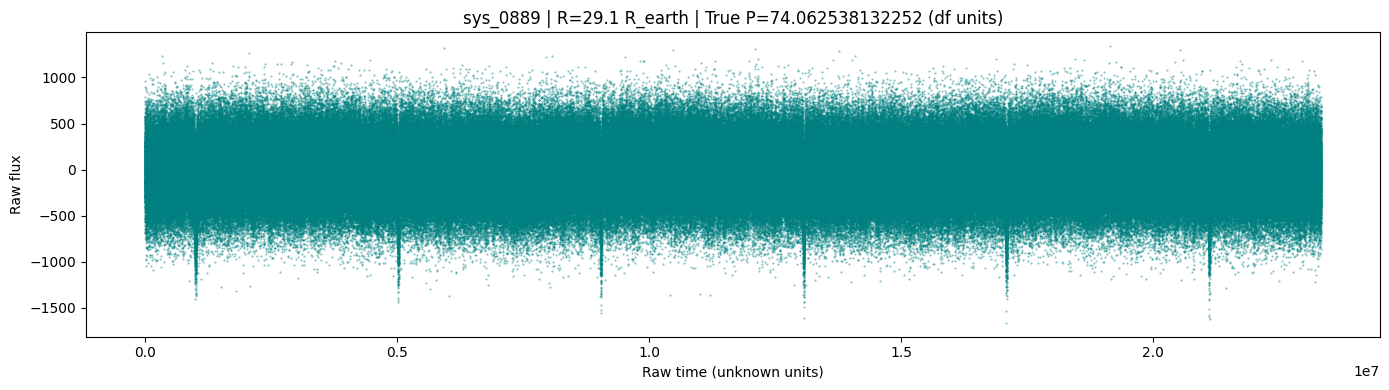

In [136]:
def diagnose_one_system(df_analysis):
    # Pick the system with the largest planet radius
    transit_df = df_analysis[df_analysis['anomaly_class'].isin([2, 3])].copy()
    row = transit_df.loc[transit_df['transit_radius_earth'].idxmax()]
    sys_id = 'sys_0889'
    true_p = row['transit_period']
    true_r = row['transit_radius_earth']
    
    print(f"System: {sys_id}")
    print(f"True period from df: {true_p} (units unknown — will infer)")
    print(f"Planet radius: {true_r:.2f} R_earth")
    print(f"Full row:\n{row}\n")
    
    # Load raw data
    time, flux = load_classifier_lightcurve(f"outputs/{sys_id}/")
    
    print(f"Time array: min={time.min():.2f}, max={time.max():.2f}, N={len(time)}")
    print(f"Time span: {time.max() - time.min():.2f}  <-- what units does this look like?")
    print(f"Median cadence: {np.median(np.diff(time)):.4f}")
    print(f"\nFlux array: min={flux.min():.4f}, max={flux.max():.4f}, median={np.median(flux):.4f}")
    
    # Plot raw time vs flux, no processing
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(time, flux, '.', ms=1, alpha=0.5, color='teal')
    ax.set_xlabel("Raw time (unknown units)")
    ax.set_ylabel("Raw flux")
    ax.set_title(f"{sys_id} | R={true_r:.1f} R_earth | True P={true_p} (df units)")
    plt.tight_layout()
    plt.show()

diagnose_one_system(df)

Baseline: 270.0 days
True period: 46.533 days
Expected ~5.8 transits in baseline
Durations used: [0.05 0.1  0.2  0.5  0.8 ] days

BLS best period:  46.538 d  (true: 46.533 d)
Period ratio:     1.0001  (1.0 = perfect)
Depth:            595.6 ppm
Duration:         4.80 hours


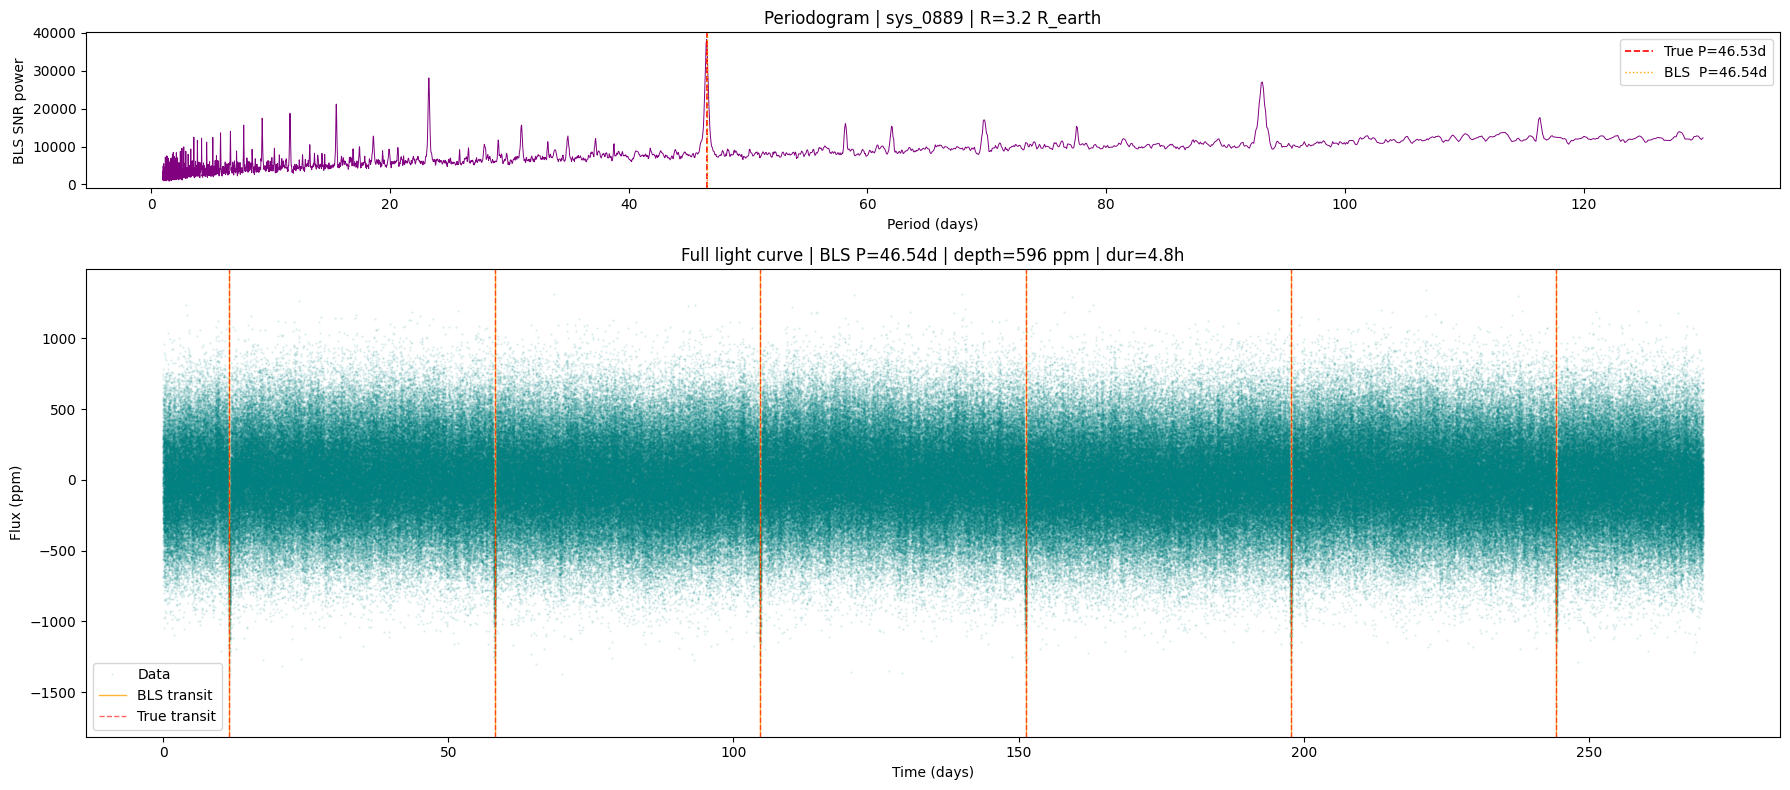

In [141]:
def bls_ideal_case(df_analysis):
    sys_id = "sys_0889"
    row = df_analysis[df_analysis['system_id'] == sys_id].iloc[0]
    true_p = row['transit_period']   # days
    true_r = row['transit_radius_earth']

    time, flux = load_classifier_lightcurve(f"outputs/{sys_id}/")
    t = time / 86400.0
    y = flux

    print(f"Baseline: {t.max() - t.min():.1f} days")
    print(f"True period: {true_p:.3f} days")
    print(f"Expected ~{(t.max()-t.min())/true_p:.1f} transits in baseline")

    periods   = np.geomspace(1.0, 130.0, 5000)
    durations = np.array([0.05, 0.1, 0.2, 0.5, 0.8])
    durations = durations[durations < 0.9 * periods.min()]
    print(f"Durations used: {durations} days")

    model  = BoxLeastSquares(t, y)
    result = model.power(periods, duration=durations, objective="snr")

    best_idx   = np.nanargmax(result.power)
    best_p     = result.period[best_idx]
    best_t0    = result.transit_time[best_idx]
    best_dur   = result.duration[best_idx]
    best_depth = result.depth[best_idx]

    print(f"\nBLS best period:  {best_p:.3f} d  (true: {true_p:.3f} d)")
    print(f"Period ratio:     {best_p/true_p:.4f}  (1.0 = perfect)")
    print(f"Depth:            {best_depth:.1f} ppm")
    print(f"Duration:         {best_dur*24:.2f} hours")

    # Predicted transit times from BLS t0
    bls_transits  = np.arange(best_t0, t.max(), best_p)
    bls_transits  = bls_transits[bls_transits >= t.min()]

    # Predicted transit times from true period (anchor to first BLS transit)
    true_transits = np.arange(best_t0, t.max(), true_p)
    true_transits = true_transits[true_transits >= t.min()]

    fig, axes = plt.subplots(2, 1, figsize=(18, 8), gridspec_kw={'height_ratios': [1, 3]})

    # Periodogram
    axes[0].plot(result.period, result.power, color='purple', lw=0.7)
    axes[0].axvline(true_p, color='red',    lw=1.2, linestyle='--', label=f'True P={true_p:.2f}d')
    axes[0].axvline(best_p, color='orange', lw=1.0, linestyle=':',  label=f'BLS  P={best_p:.2f}d')
    axes[0].set_xlabel("Period (days)")
    axes[0].set_ylabel("BLS SNR power")
    axes[0].set_title(f"Periodogram | {sys_id} | R={true_r:.1f} R_earth")
    axes[0].legend()

    # Full light curve with transit markers
    axes[1].plot(t, y, '.', ms=1, alpha=0.15, color='teal', label='Data')
    for i, tc in enumerate(bls_transits):
        axes[1].axvline(tc, color='orange', lw=1.0, alpha=0.8,
                        label='BLS transit' if i == 0 else None)
    for i, tc in enumerate(true_transits):
        axes[1].axvline(tc, color='red', lw=1.0, linestyle='--', alpha=0.6,
                        label='True transit' if i == 0 else None)

    axes[1].set_xlabel("Time (days)")
    axes[1].set_ylabel("Flux (ppm)")
    axes[1].set_title(f"Full light curve | BLS P={best_p:.2f}d | depth={best_depth:.0f} ppm | dur={best_dur*24:.1f}h")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

bls_ideal_case(df)

sys_1047 | R=  2.6 Re | True P=   2.22d | BLS P=   2.22d | ratio=1.000 | depth=   371.1 ppm | OK


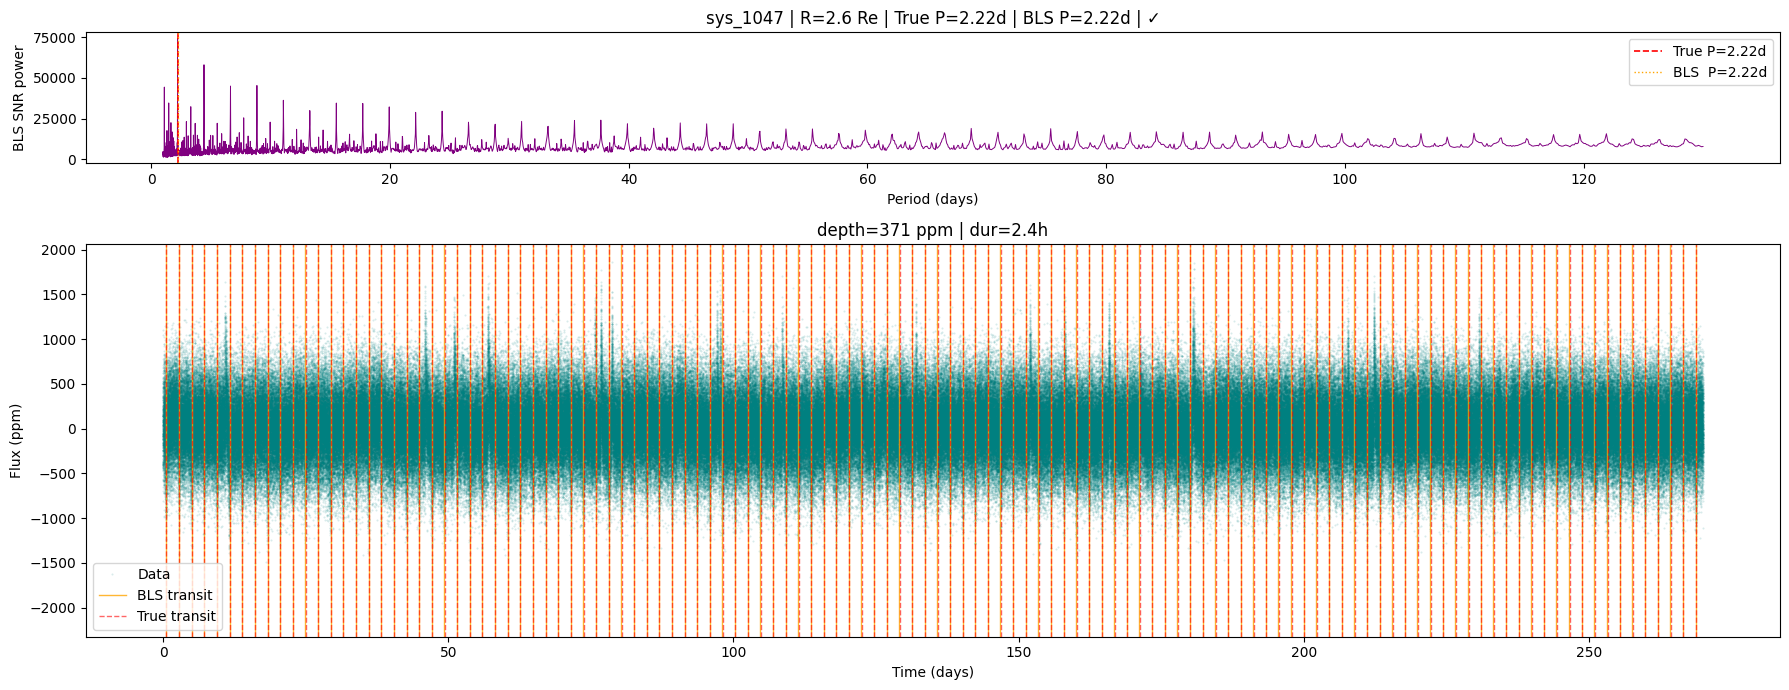

sys_1480 | R=  0.7 Re | True P=   3.31d | BLS P=  17.97d | ratio=5.432 | depth=    39.0 ppm | FAIL


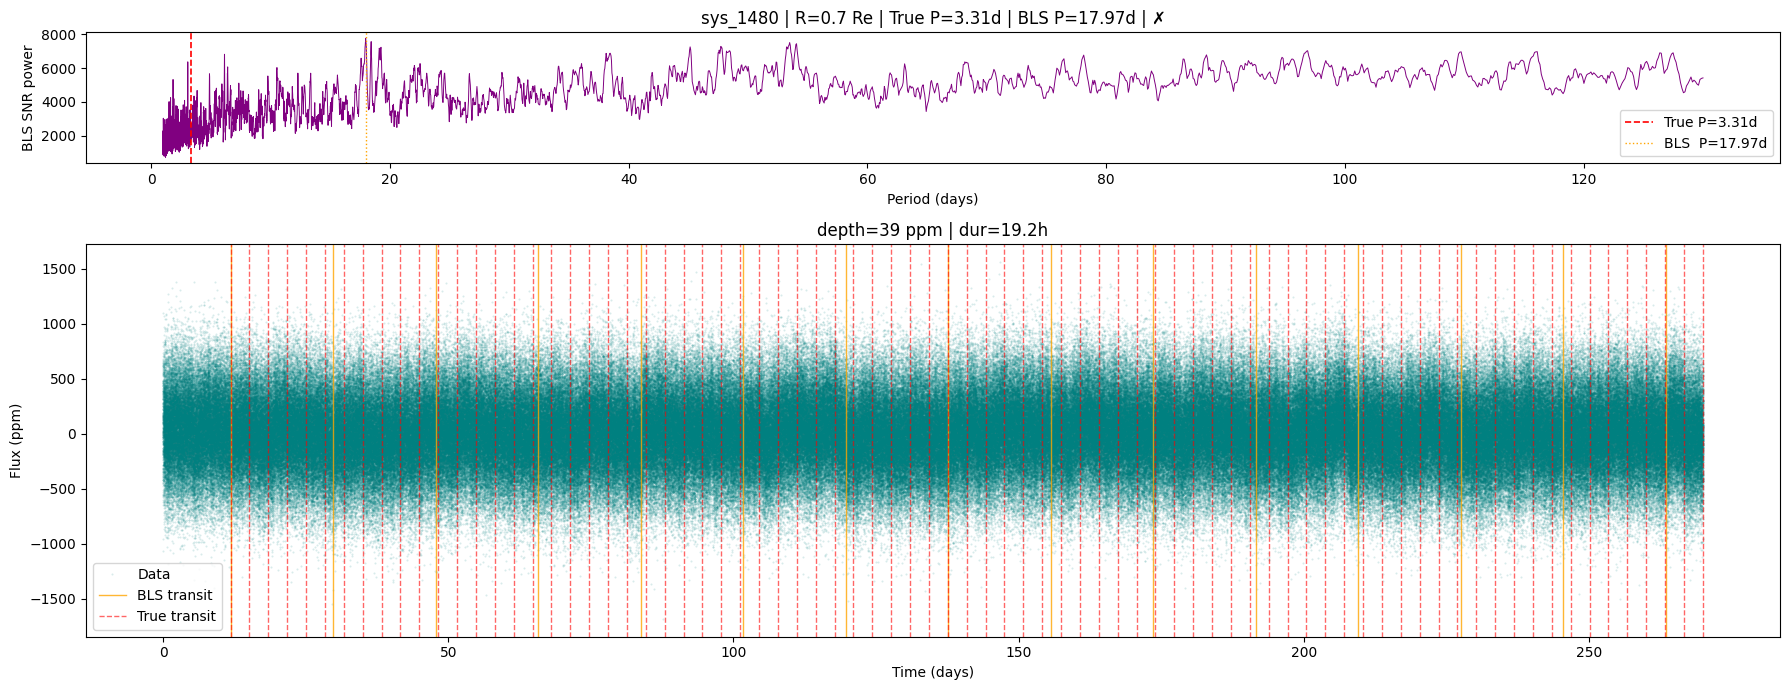

sys_1485 | R=  3.1 Re | True P=  34.92d | BLS P=  17.97d | ratio=0.515 | depth=    39.0 ppm | OK


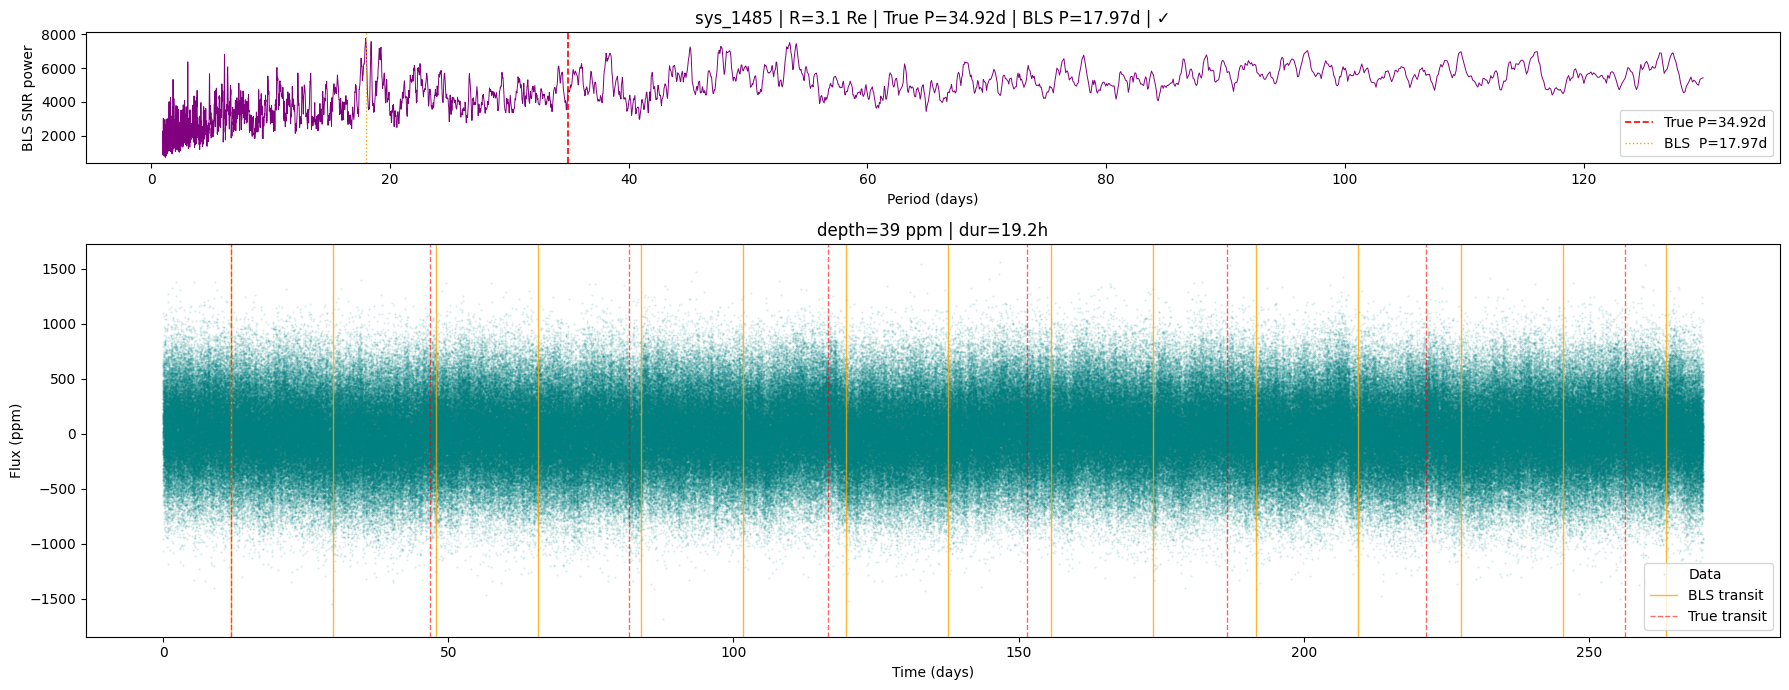

sys_1339 | R=  2.4 Re | True P=  54.04d | BLS P=  54.01d | ratio=0.999 | depth=   449.5 ppm | OK


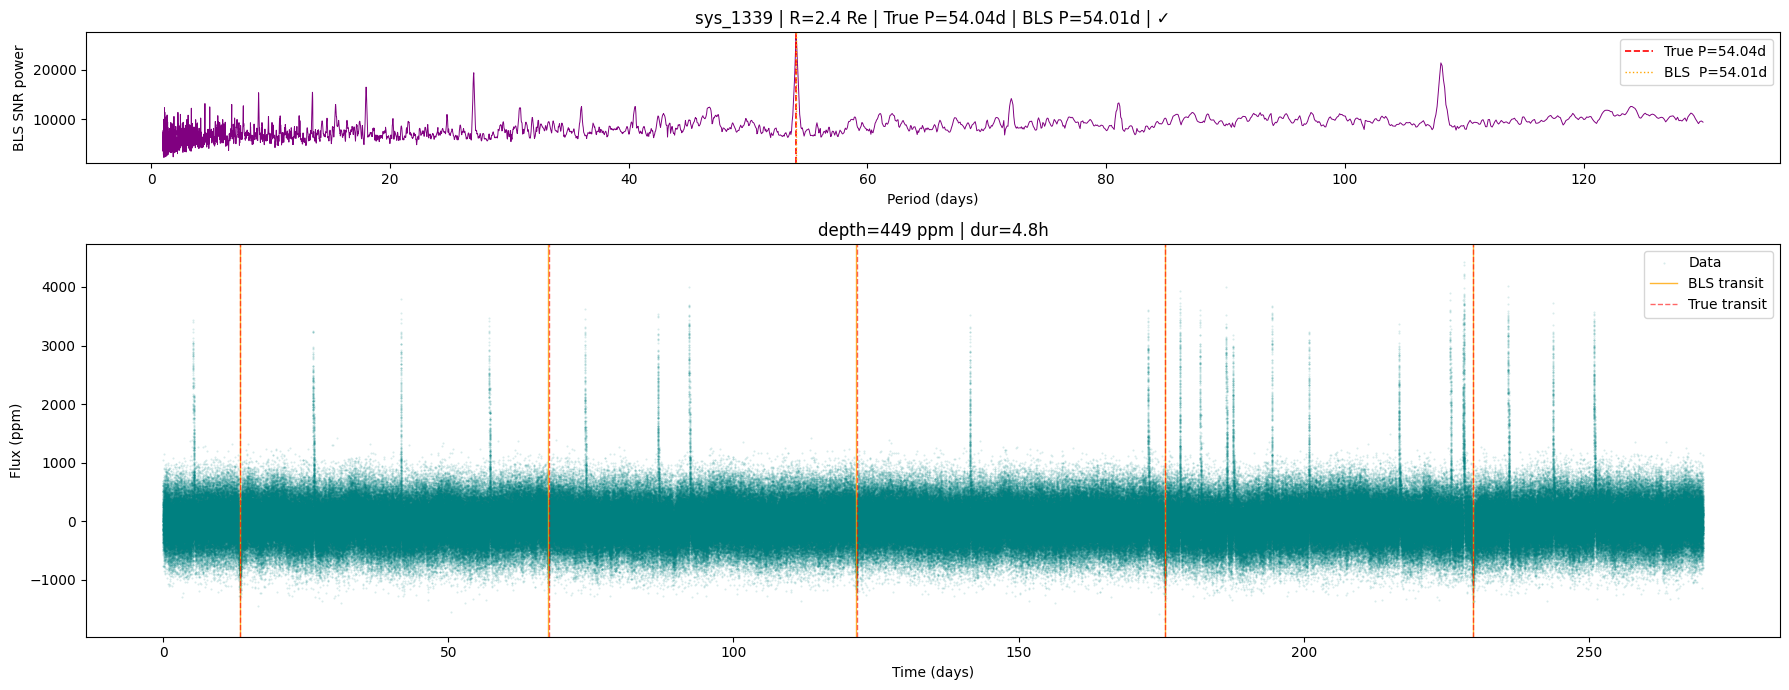

sys_0812 | R=  0.5 Re | True P=   8.35d | BLS P=  96.60d | ratio=11.563 | depth=    70.1 ppm | FAIL


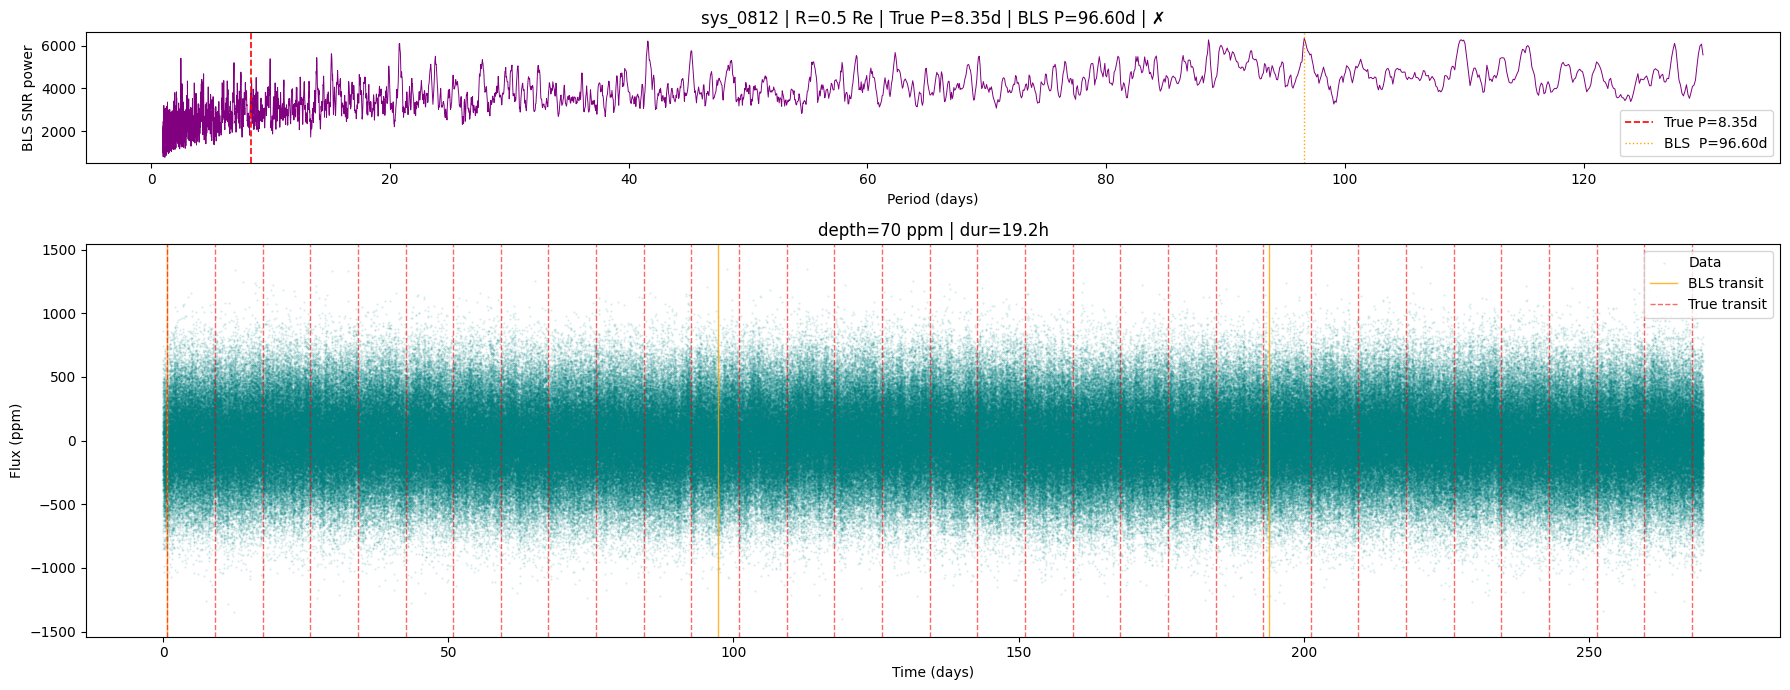

sys_1372 | R=  7.8 Re | True P=  55.41d | BLS P=  55.40d | ratio=1.000 | depth=  2197.8 ppm | OK


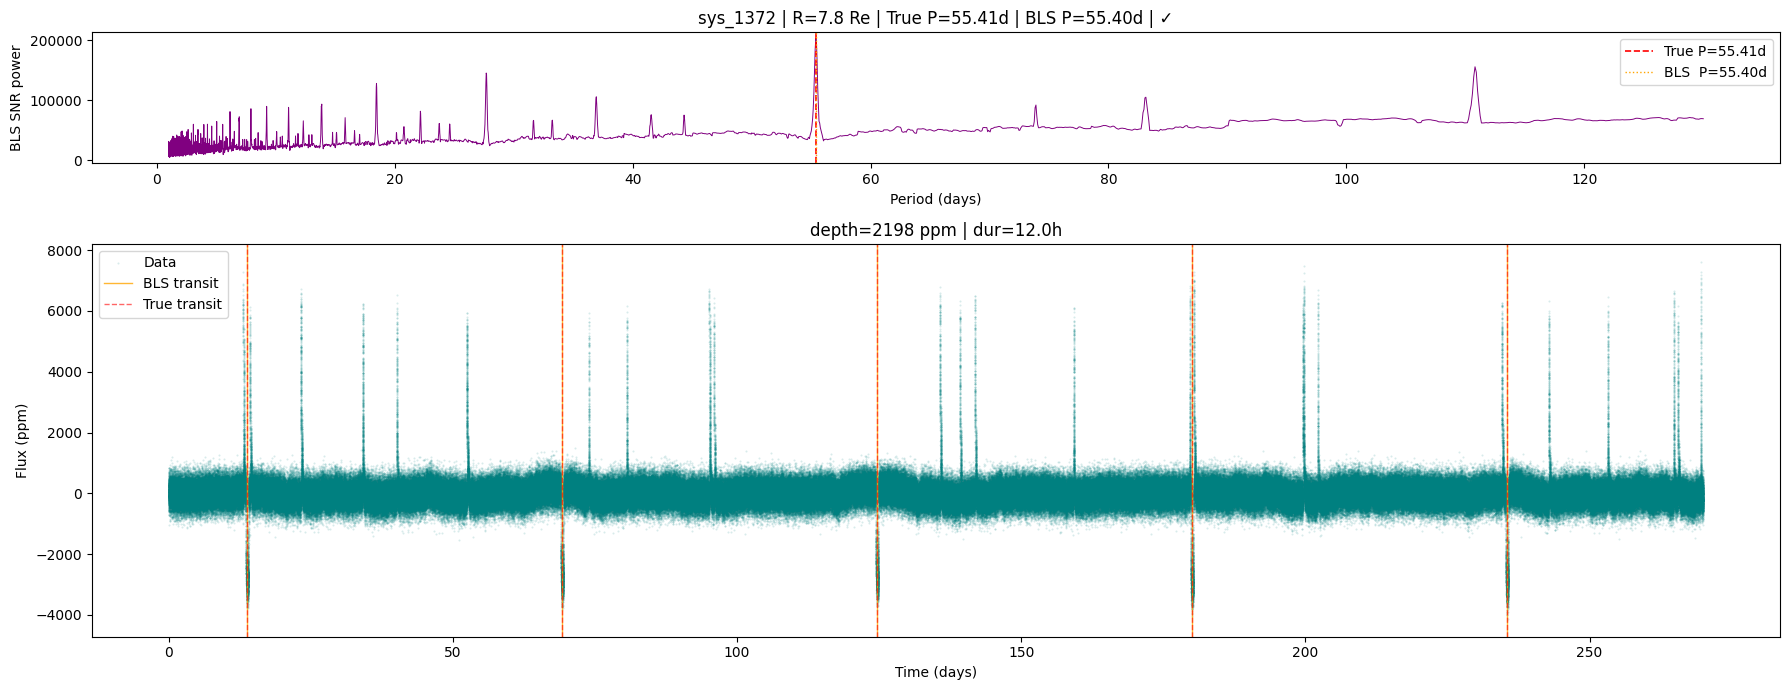

sys_1274 | R=  1.1 Re | True P=  48.34d | BLS P=  50.55d | ratio=1.046 | depth=    63.6 ppm | OK


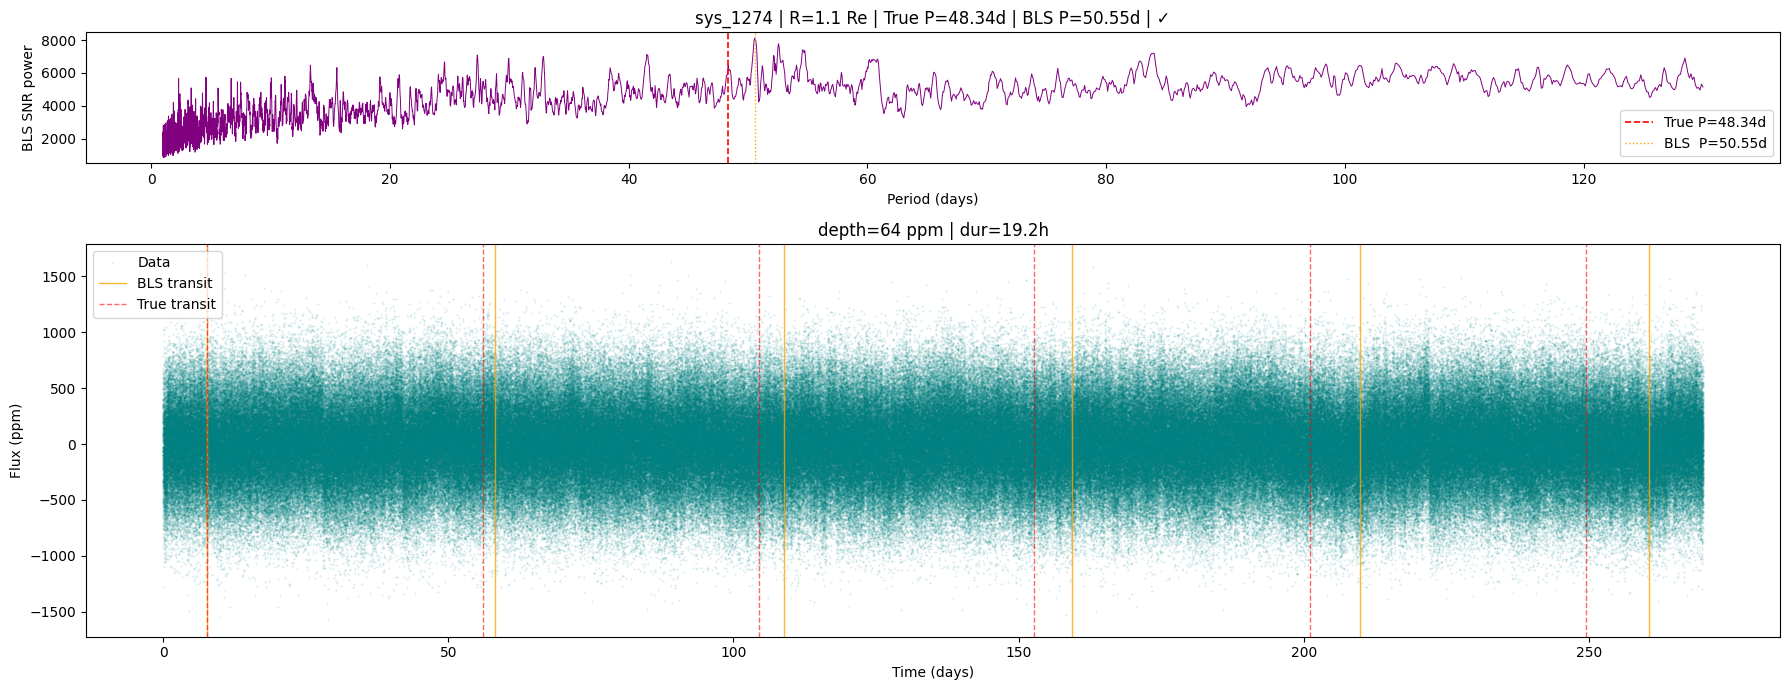

sys_1029 | R=  3.0 Re | True P=  62.42d | BLS P=  62.45d | ratio=1.000 | depth=  1008.8 ppm | OK


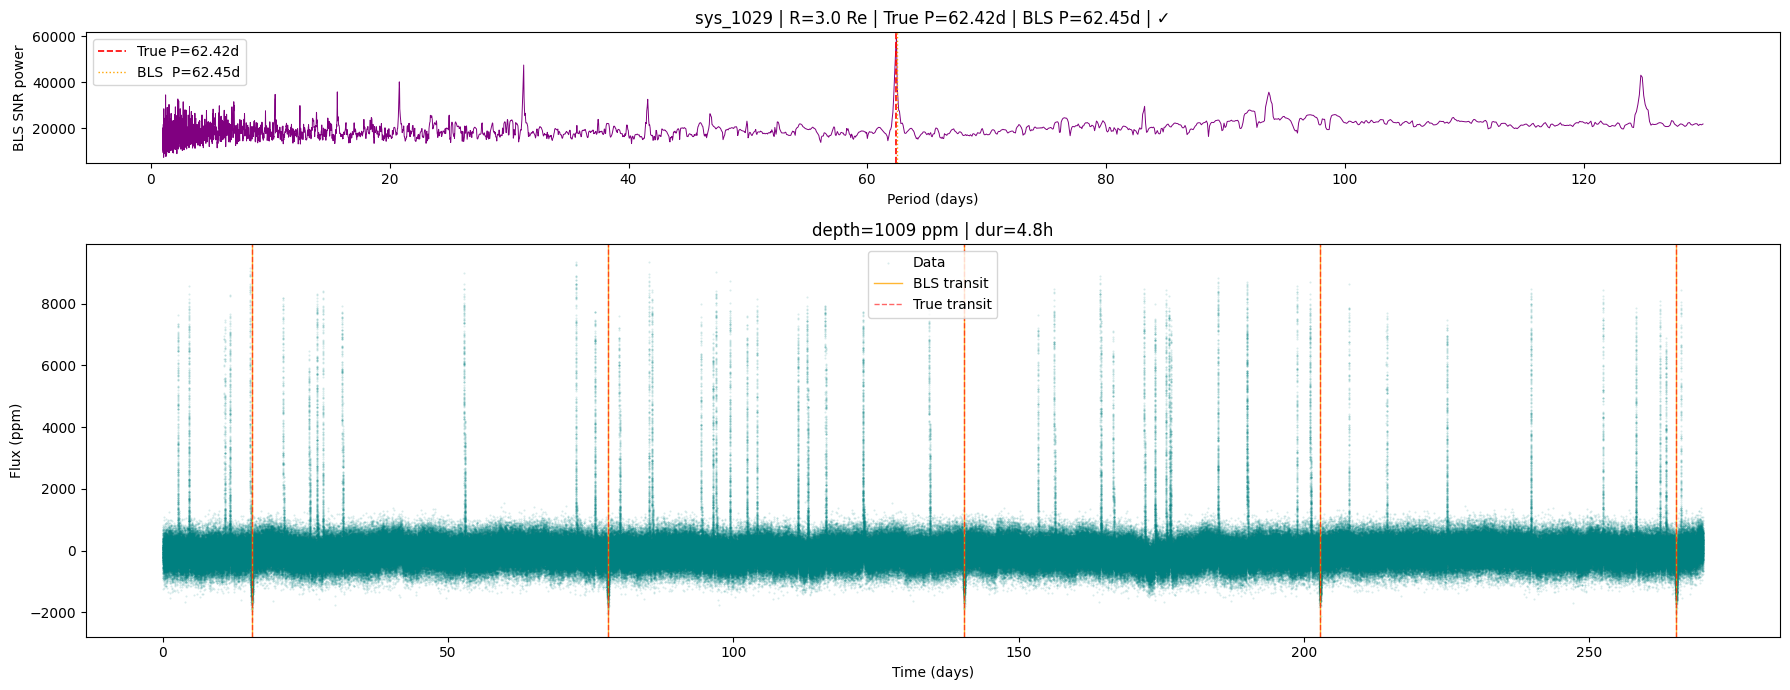

TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

In [142]:
def bls_batch_test(df_analysis, n=10, seed=42):
    transit_df = df_analysis[df_analysis['anomaly_class'].isin([2, 3])].copy()
    sample = transit_df.sample(n=n, random_state=seed)

    for _, row in sample.iterrows():
        sys_id = row['system_id']
        true_p = row['transit_period']
        true_r = row['transit_radius_earth']

        time, flux = load_classifier_lightcurve(f"outputs/{sys_id}/")
        t = time / 86400.0
        y = flux

        periods   = np.geomspace(1.0, 130.0, 5000)
        durations = np.array([0.05, 0.1, 0.2, 0.5, 0.8])
        durations = durations[durations < 0.9 * periods.min()]

        model  = BoxLeastSquares(t, y)
        result = model.power(periods, duration=durations, objective="snr")

        best_idx   = np.nanargmax(result.power)
        best_p     = result.period[best_idx]
        best_t0    = result.transit_time[best_idx]
        best_dur   = result.duration[best_idx]
        best_depth = result.depth[best_idx]

        ratio = best_p / true_p
        # Check for simple harmonics/aliases: 0.5x, 1x, 2x
        nearest_harmonic = min([0.5, 1.0, 2.0, 3.0], key=lambda h: abs(ratio - h))
        ok = abs(ratio - nearest_harmonic) < 0.05

        print(f"{sys_id} | R={true_r:5.1f} Re | True P={true_p:7.2f}d | "
              f"BLS P={best_p:7.2f}d | ratio={ratio:.3f} | "
              f"depth={best_depth:8.1f} ppm | {'OK' if ok else 'FAIL'}")

        bls_transits  = np.arange(best_t0, t.max(), best_p)
        bls_transits  = bls_transits[bls_transits >= t.min()]
        true_transits = np.arange(best_t0, t.max(), true_p)
        true_transits = true_transits[true_transits >= t.min()]

        fig, axes = plt.subplots(2, 1, figsize=(18, 7),
                                 gridspec_kw={'height_ratios': [1, 3]})

        axes[0].plot(result.period, result.power, color='purple', lw=0.7)
        axes[0].axvline(true_p, color='red',    lw=1.2, linestyle='--', label=f'True P={true_p:.2f}d')
        axes[0].axvline(best_p, color='orange', lw=1.0, linestyle=':',  label=f'BLS  P={best_p:.2f}d')
        axes[0].set_xlabel("Period (days)")
        axes[0].set_ylabel("BLS SNR power")
        axes[0].set_title(f"{sys_id} | R={true_r:.1f} Re | True P={true_p:.2f}d | BLS P={best_p:.2f}d | {'✓' if ok else '✗'}")
        axes[0].legend()

        axes[1].plot(t, y, '.', ms=1, alpha=0.15, color='teal', label='Data')
        for i, tc in enumerate(bls_transits):
            axes[1].axvline(tc, color='orange', lw=1.0, alpha=0.8,
                            label='BLS transit' if i == 0 else None)
        for i, tc in enumerate(true_transits):
            axes[1].axvline(tc, color='red', lw=1.0, linestyle='--', alpha=0.6,
                            label='True transit' if i == 0 else None)
        axes[1].set_xlabel("Time (days)")
        axes[1].set_ylabel("Flux (ppm)")
        axes[1].set_title(f"depth={best_depth:.0f} ppm | dur={best_dur*24:.1f}h")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

bls_batch_test(df, n=10)